# Logistic Regression — Full Deep Dive

In [ ]:
The Story First 📖

Remember Linear Regression:
study hours → marks (a number)

Now new problem:
study hours → Pass or Fail? (yes or no!)

Can we use Linear Regression for this?
Let's see...



Why Linear Regression FAILS for classification:
Linear Regression output:
study 1hr  → 25 marks
study 5hrs → 65 marks
study 10hrs → 105 marks  ← greater than 100! impossible!

For Pass/Fail we need output between 0 and 1 only!
0 = Fail
1 = Pass

Linear Regression can go above 1 and below 0 ❌
Logistic Regression stays between 0 and 1 ✅

# The Sigmoid Function — Heart of Logistic Regression!
This is what makes Logistic Regression special:

In [ ]:
Sigmoid converts ANY number to between 0 and 1!

Input  → Output
-10    → 0.00005  (almost 0)
-5     → 0.007    (almost 0)
 0     → 0.5      (exactly middle)
 5     → 0.993    (almost 1)
 10    → 0.99995  (almost 1)

In [ ]:
Formula:
sigmoid(x) = 1
             ─────────
             1 + e^(-x)
Shape:
1 |          _________
  |        /
  |       /
0.5|------/------------
  |     /
  |   /
0 |__/
  |________________
        x

S shaped curve!
never goes below 0
never goes above 1

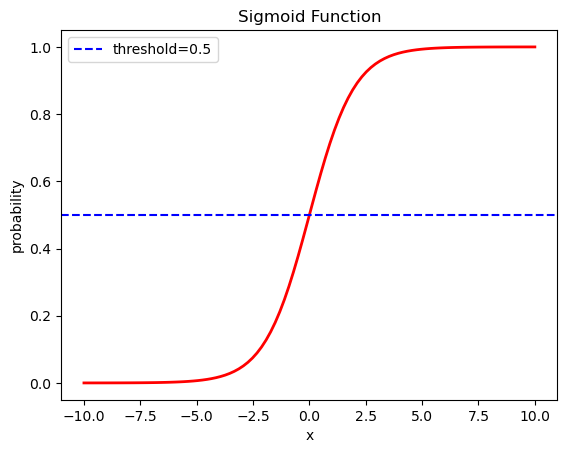

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.plot(x, y, color="red", linewidth=2)
plt.axhline(y=0.5, color="blue",
            linestyle="--", label="threshold=0.5")
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("probability")
plt.legend()
plt.show()

In [ ]:
How Logistic Regression Works:


Step 1 → takes input (study hours)
Step 2 → calculates linear combination
         z = w×x + b
Step 3 → passes through sigmoid
         probability = sigmoid(z)
Step 4 → applies threshold
         if probability >= 0.5 → Pass (1)
         if probability <  0.5 → Fail (0)

In [ ]:
study hours → z = w×x+b → sigmoid → probability → class

2 hours  → z=-2 → sigmoid → 0.12 → Fail ❌
5 hours  → z= 0 → sigmoid → 0.50 → Pass ✅ (borderline!)
8 hours  → z= 2 → sigmoid → 0.88 → Pass ✅
10 hours → z= 4 → sigmoid → 0.98 → Pass ✅

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix,classification_report

# data
data = {
    "study_hours": [1,2,3,4,5,6,7,8,9,10,
                    2,3,4,5,6,7,8,9,10,1],
    "result"     : [0,0,0,0,1,1,1,1,1,1,
                    0,0,1,0,1,1,1,1,1,0]
    # 0 = Fail, 1 = Pass
}

df= pd.DataFrame(data)

X= df[["study_hours"]]
y=df["result"]

# split 
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42
)

model= LogisticRegression( C=1.0,              # regularization strength
    max_iter=100,       # maximum iterations
    random_state=42    ) # reproducibility

model.fit(X_train,y_train)

# predict class 0 ,1 
y_pred= model.predict(X_test)

# predict probability
y_prob= model.predict_proba(X_test)

print("predicted class:",y_pred)
print("Predicted probability:", y_prob)
print("Actual               :", list(y_test))


predicted class: [0 1 1 0]
Predicted probability: [[0.98170574 0.01829426]
 [0.0057113  0.9942887 ]
 [0.05345342 0.94654658]
 [0.94479522 0.05520478]]
Actual               : [0, 1, 1, 0]


In [ ]:
# Parameters Explained ------ btw without para upper one is same 



C controls how strict the model is

High C (C=100) → model tries to fit
                 every point perfectly
               → might overfit! ❌

Low C  (C=0.01) → model is more relaxed
                → might underfit! ❌

C=1.0 → balanced, good default ✅

Simple analogy:
High C = student memorizes everything
Low C  = student learns only main concepts
C=1    = balanced student ✅

In [ ]:
max_iter=100 — Maximum Iterations:


how many times model adjusts itself

too low  → model didn't learn enough
too high → wastes time

if you get warning:
"model didn't converge"
→ increase max_iter=1000 ✅

In [ ]:
predict_proba output:

y_prob = [[0.88, 0.12],
          [0.23, 0.77]]

Each row = one prediction
Column 0 = probability of Fail (0)
Column 1 = probability of Pass (1)

Row 1: 88% chance Fail, 12% chance Pass → Fail
Row 2: 23% chance Fail, 77% chance Pass → Pass